# Analasing neuroComBat behaivor when imbalance across sites.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression

from uniharmony import verbosity
from uniharmony.combat import NeuroComBat
from uniharmony.datasets import make_multisite_classification
from uniharmony.plot import plot_decision_boundary_2d


sns.set_theme(style="whitegrid")
verbosity("warning")
combat = NeuroComBat()
clf = LogisticRegression()

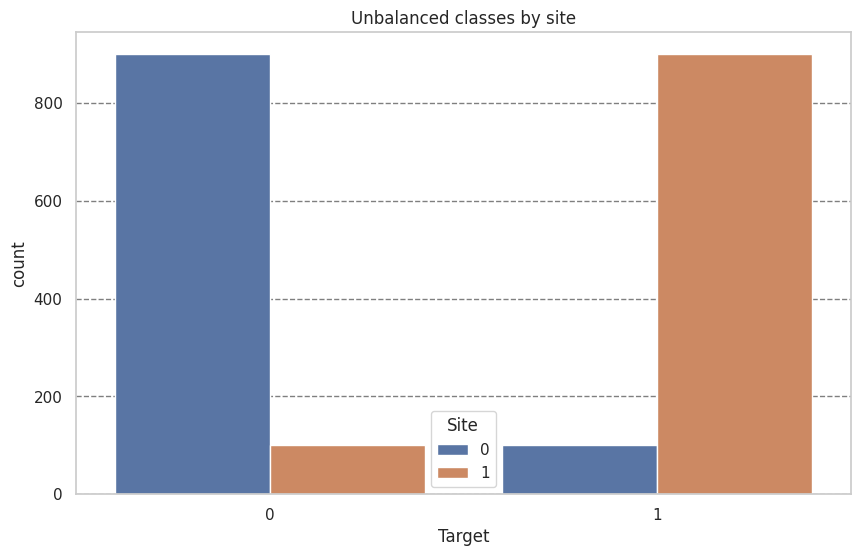

In [2]:
X, y, sites = make_multisite_classification(
    n_classes=2,
    n_samples=2000,
    n_sites=2,
    n_features=2,
    signal_strength=2,
    site_effect_strength=0,
    balance_per_site=[0.1, 0.9],
)
df = pd.DataFrame({"Target": y, "Site": sites})

plt.figure(figsize=[10, 6])
plt.title("Unbalanced classes by site")
sns.countplot(df, x="Target", hue="Site")
plt.grid(axis="y", color="black", alpha=0.5, linestyle="--")

Original data accuracy: 0.8475
Harmonized data accuracy: 0.6195


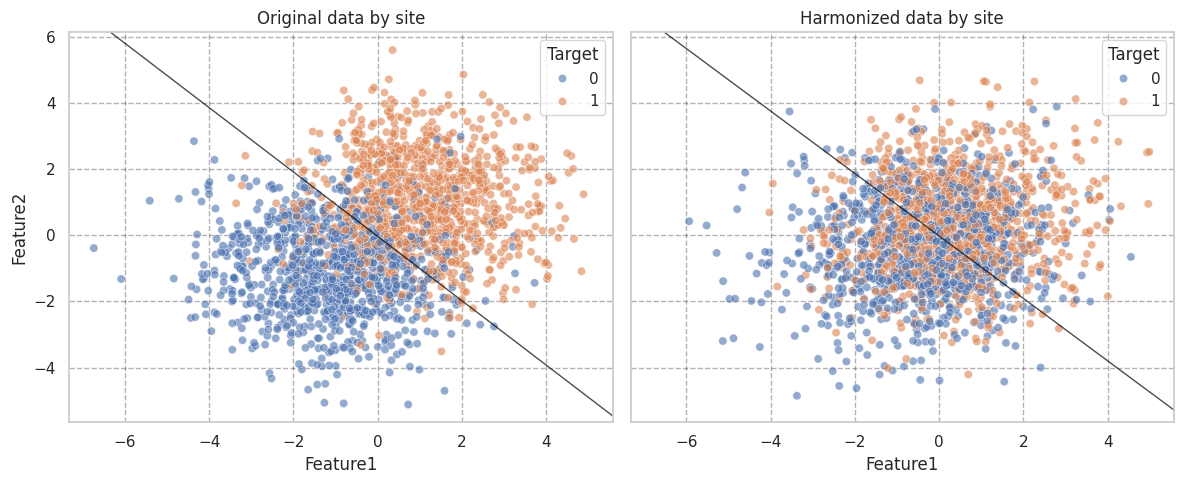

In [3]:
# Note that we are harmonizing the whole dataset, which is not how it would be used in practice.
# This is just to illustrate the effect of harmonization.
X_harmonized = combat.fit_transform(X, sites)
df_orig = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df_orig["Site"] = sites
df_orig["Target"] = y
df_orig["Phase"] = "Original"

df_harm = pd.DataFrame(X_harmonized, columns=["Feature1", "Feature2"])
df_harm["Site"] = sites
df_harm["Target"] = y
df_harm["Phase"] = "Harmonized"


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
sns.scatterplot(data=df_orig, x="Feature1", y="Feature2", hue="Target", alpha=0.6, ax=axes[0])
axes[0].set_title("Original data by site")
axes[0].grid(alpha=0.3, color="black", linestyle="--")

sns.scatterplot(data=df_harm, x="Feature1", y="Feature2", hue="Target", alpha=0.6, ax=axes[1])
axes[1].set_title("Harmonized data by site")
axes[1].grid(alpha=0.3, color="black", linestyle="--")
plt.tight_layout()

# Note that we are fitting and evaluation in the whole dataset, which is not how it would be used in practice.
# This is just to illustrate the effect of harmonization on the decision boundary.
clf.fit(X, y)
print(f"Original data accuracy: {clf.score(X, y)}")
plot_decision_boundary_2d(axes[0], clf)

clf.fit(X_harmonized, y)
print(f"Harmonized data accuracy: {clf.score(X_harmonized, y)}")
plot_decision_boundary_2d(axes[1], clf)

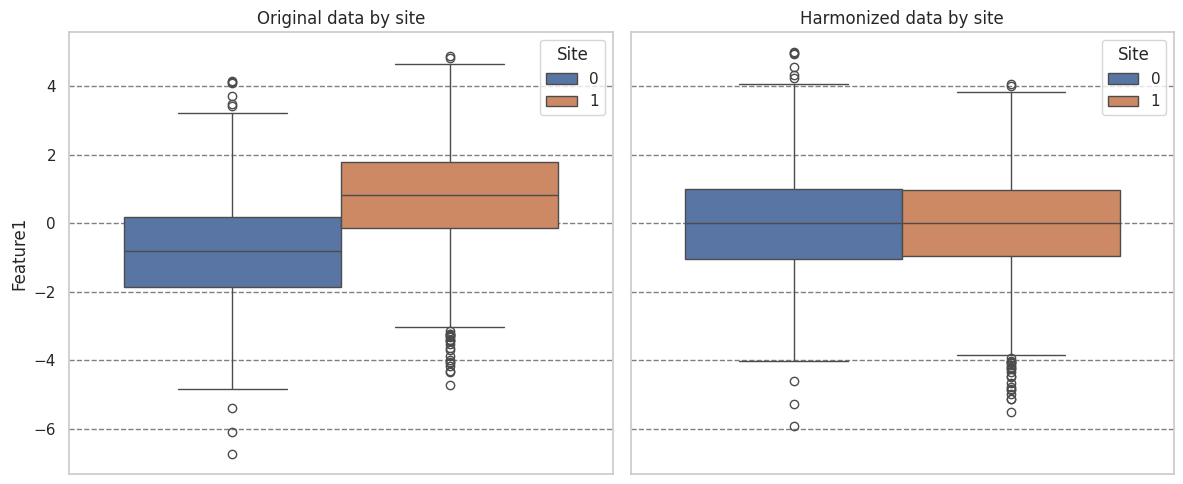

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
sns.boxplot(data=df_orig, y="Feature1", hue="Site", ax=axes[0])
axes[0].set_title("Original data by site")
axes[0].grid(axis="y", color="black", alpha=0.5, linestyle="--")
sns.boxplot(data=df_harm, y="Feature1", hue="Site", ax=axes[1])
axes[1].set_title("Harmonized data by site")
axes[1].grid(axis="y", color="black", alpha=0.5, linestyle="--")
plt.tight_layout()

# Example preserving the target as covariate **WRONG IN ML CONTEXT, ONLY FOR DEMOSTRATION PROPUSES**

2026-04-08 16:39:16 [warning  ] You specified categorical and/or continuous covariates to be preserved. If you intend to build a machine learning (ML) model,then make sure that you DO *NOT* preserve the ML model's target as covariate. You will be required to provide the covariate also at transform time, and this will produce data leakage. If you are performing a statistical analysis and want to preserve a variable of interest, then it is correct to specify it as covariate.
Original data accuracy: 0.8475
Harmonized data accuracy: 0.85


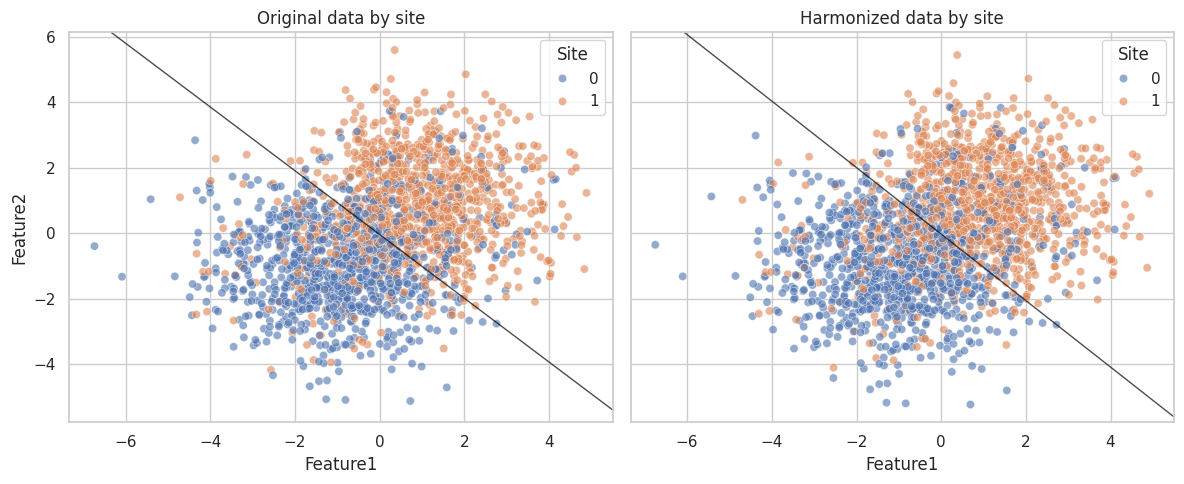

In [5]:
combat = NeuroComBat()
# This is the key line: we need to include the target variable as a covariate
# to preserve its relationship with the features during harmonization
# For ML, this is wrong in two ways. First it leaks information from the test set into the training set.
# Second, it applies the transformation on the whole dataset, which is not how it would be used in practice.
X_harmonized = combat.fit_transform(X, sites, categorical_covariates=y.reshape(-1, 1))
df_orig = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df_orig["Site"] = sites
df_orig["Phase"] = "Original"

df_harm = pd.DataFrame(X_harmonized, columns=["Feature1", "Feature2"])
df_harm["Site"] = sites
df_harm["Phase"] = "Harmonized"

# Plot data distribution by site before and after harmonization
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
sns.scatterplot(data=df_orig, x="Feature1", y="Feature2", hue="Site", alpha=0.6, ax=axes[0])
axes[0].set_title("Original data by site")
sns.scatterplot(data=df_harm, x="Feature1", y="Feature2", hue="Site", alpha=0.6, ax=axes[1])
axes[1].set_title("Harmonized data by site")
plt.tight_layout()

# Plot decision boundaries before and after harmonization
# Note that we are fitting and evaluation in the whole dataset, which is not how it would be used in practice.
# This is just to illustrate the effect of harmonization on the decision boundary.
clf.fit(X, y)
print(f"Original data accuracy: {clf.score(X, y)}")
plot_decision_boundary_2d(axes[0], clf)

clf.fit(X_harmonized, y)
print(f"Harmonized data accuracy: {clf.score(X_harmonized, y)}")
plot_decision_boundary_2d(axes[1], clf)

# Note that the method warns about the categorical variable being preserved.

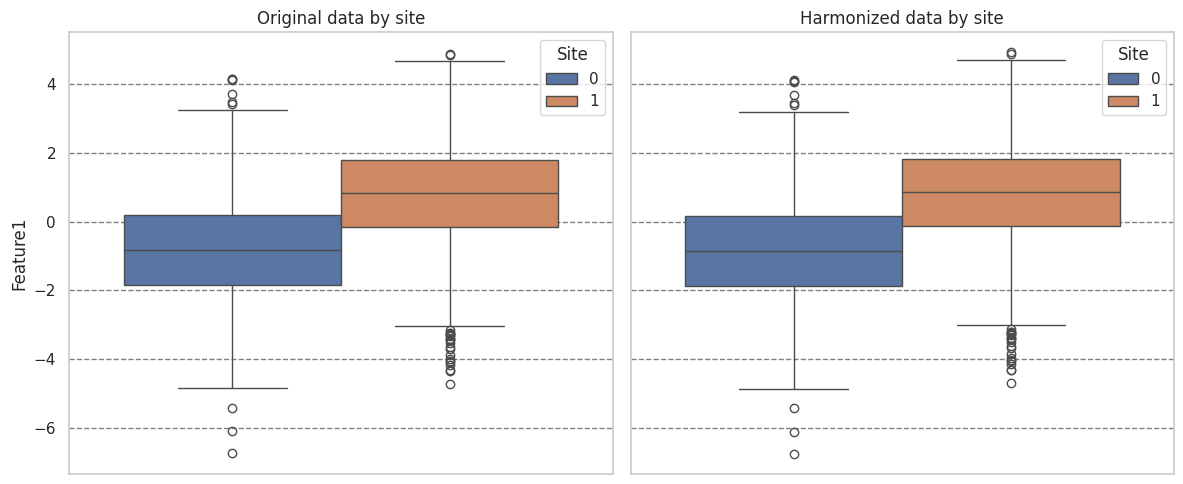

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
sns.boxplot(data=df_orig, y="Feature1", hue="Site", ax=axes[0])
axes[0].set_title("Original data by site")
axes[0].grid(axis="y", color="black", alpha=0.5, linestyle="--")
sns.boxplot(data=df_harm, y="Feature1", hue="Site", ax=axes[1])
axes[1].set_title("Harmonized data by site")
axes[1].grid(axis="y", color="black", alpha=0.5, linestyle="--")
plt.tight_layout()